## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [21]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [22]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [23]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='../data/hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [24]:

size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                      transforms.RandomVerticalFlip(), 
                                      transforms.RandomHorizontalFlip(), 
                                      transforms.GaussianBlur(3), 
                                      transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 128
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

Let's look at some images from our data 

torch.Size([3, 128, 128])


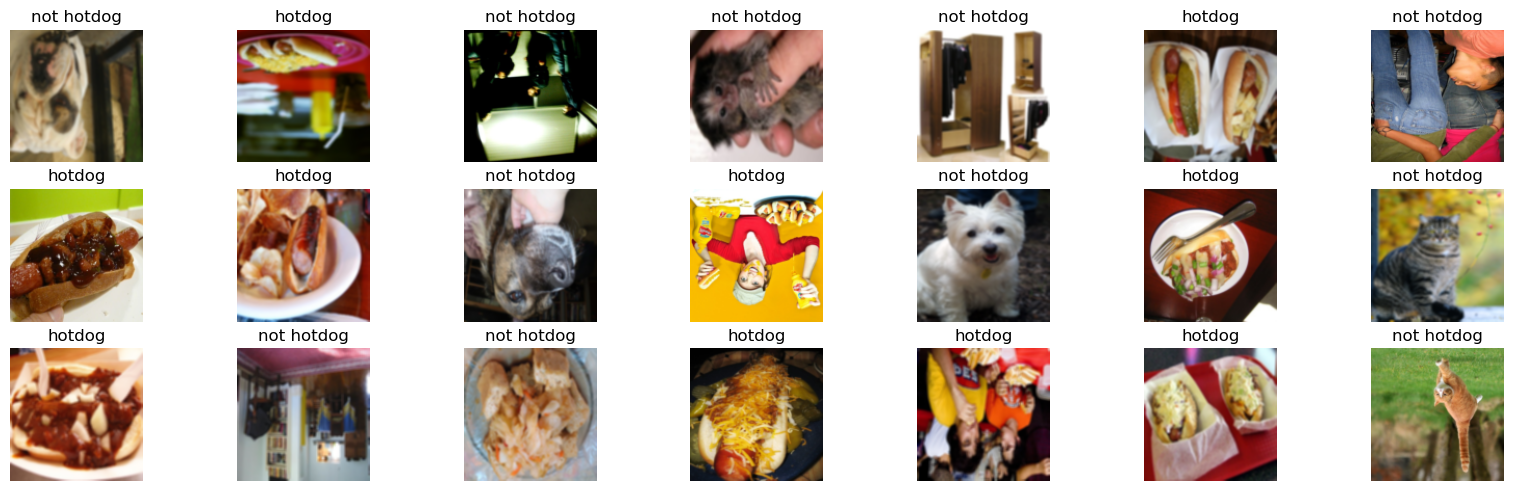

In [25]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))
print(images[0].shape)
for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [26]:

import torch
import torch.nn as nn


class VGG16(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # input size: 3x128x128
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), # ->(64,128,128)
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # ->(64,128,128)
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(kernel_size=2, stride=2),  # ->(64,64,64)
            
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # ->(128,64,64)
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),  
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # ->(128,32,32)
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # ->(256,16,16)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256*16*16, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [27]:
model = VGG16()  # Fixed: should be 2 classes for binary classification
model.to(device)
#Initialize the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9)

#Get the first minibatch
data = next(iter(train_loader))[0]
#Try running the model on a minibatch
# print('Shape of the output from the convolutional part', model.convolutional(data).shape)
model(data); #if this runs the model dimensions fit

In [28]:
num_epochs = 10
train_acc_list = []
test_acc_list = []

for epoch in tqdm(range(num_epochs), unit='epoch'):
    model.train()
    train_correct = 0
    for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        # Removed print(output) to avoid flooding output
        loss = F.cross_entropy(output, target)  # Fixed: use cross_entropy instead of nll_loss with log
        loss.backward()
        optimizer.step()
        predicted = output.argmax(1)
        train_correct += (target==predicted).sum().cpu().item()
    
    test_correct = 0
    model.eval()
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)  # Fixed: move target to device
        with torch.no_grad():
            output = model(data)
        predicted = output.argmax(1)  # Removed .cpu() since target is now on device
        test_correct += (target==predicted).sum().item()
    
    train_acc = train_correct/len(trainset)
    test_acc = test_correct/len(testset)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print("Accuracy train: {train:.1f}%\t test: {test:.1f}%".format(test=100*test_acc, train=100*train_acc))

plt.plot(range(1, num_epochs+1), train_acc_list, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), test_acc_list, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 55.0%	 test: 51.9%


  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 61.4%	 test: 51.9%


...

Accuracy train: 68.9%	 test: 56.0%


  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 71.2%	 test: 61.8%


  0%|          | 0/16 [00:00<?, ?it/s]

KeyboardInterrupt: 